In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import norm
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['font.size'] = 15

In [2]:
files = ! ls Final_Chunk*.pkl
bucket = []
for item in files:
    bucket.append( pd.read_pickle(item) )
df = pd.concat(bucket, ignore_index=True)
df

,mass,dcaXY,pt,cos_pointing,decay_length
0,1.821499,-5.468567e-06,0.775502,0.923646,0.007234
1,1.832552,-3.615033e-06,1.448730,0.962763,0.004363
2,1.842711,-9.833554e-06,2.671746,0.991940,0.027235
3,2.077747,-6.832794e-06,2.760309,0.991226,0.020889
4,2.127117,-3.602634e-05,2.288202,0.997269,0.014921
...,...,...,...,...,...
3490373,1.866142,-2.508968e-05,2.268574,0.963181,0.008864
3490374,1.882342,2.048275e-05,0.286284,0.930441,0.091818
3490375,1.965956,-5.525509e-07,0.575086,0.901557,0.011760
3490376,1.573312,-5.736692e-06,2.072498,0.950612,0.010954


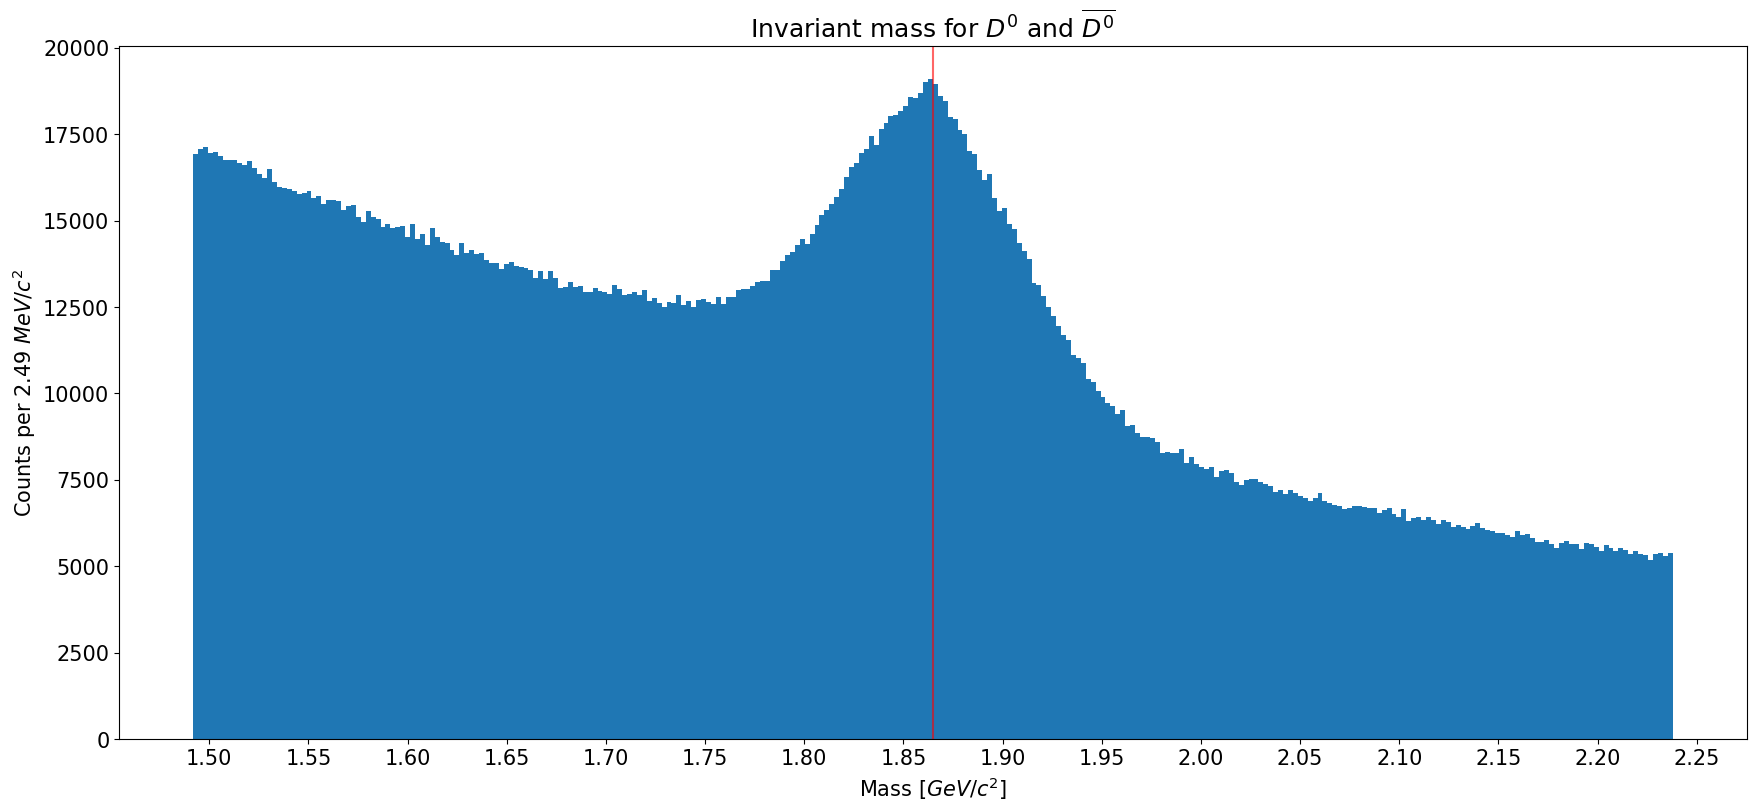

In [3]:
N_BINS = 300
m_d0 = 1.86484
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
STEP = (MAX_MASS-MIN_MASS)/N_BINS

fig, ax = plt.subplots(figsize=(21,9))
counts, edges, graph = plt.hist(df["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid")
plt.xlabel(r"Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {STEP*1000:.2f} $MeV/c^2$")
plt.xticks(np.arange(1.50,2.26, 0.05))
plt.axvline(x=m_d0, color="red", alpha=0.6)
plt.title(r"Invariant mass for $D^0$ and $\overline{D^0}$")
plt.show()

/tmp/ipykernel_16149/2434548682.py:6: RuntimeWarning: overflow encountered in exp
  return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal * np.exp( ( x - off ) / tau ) )


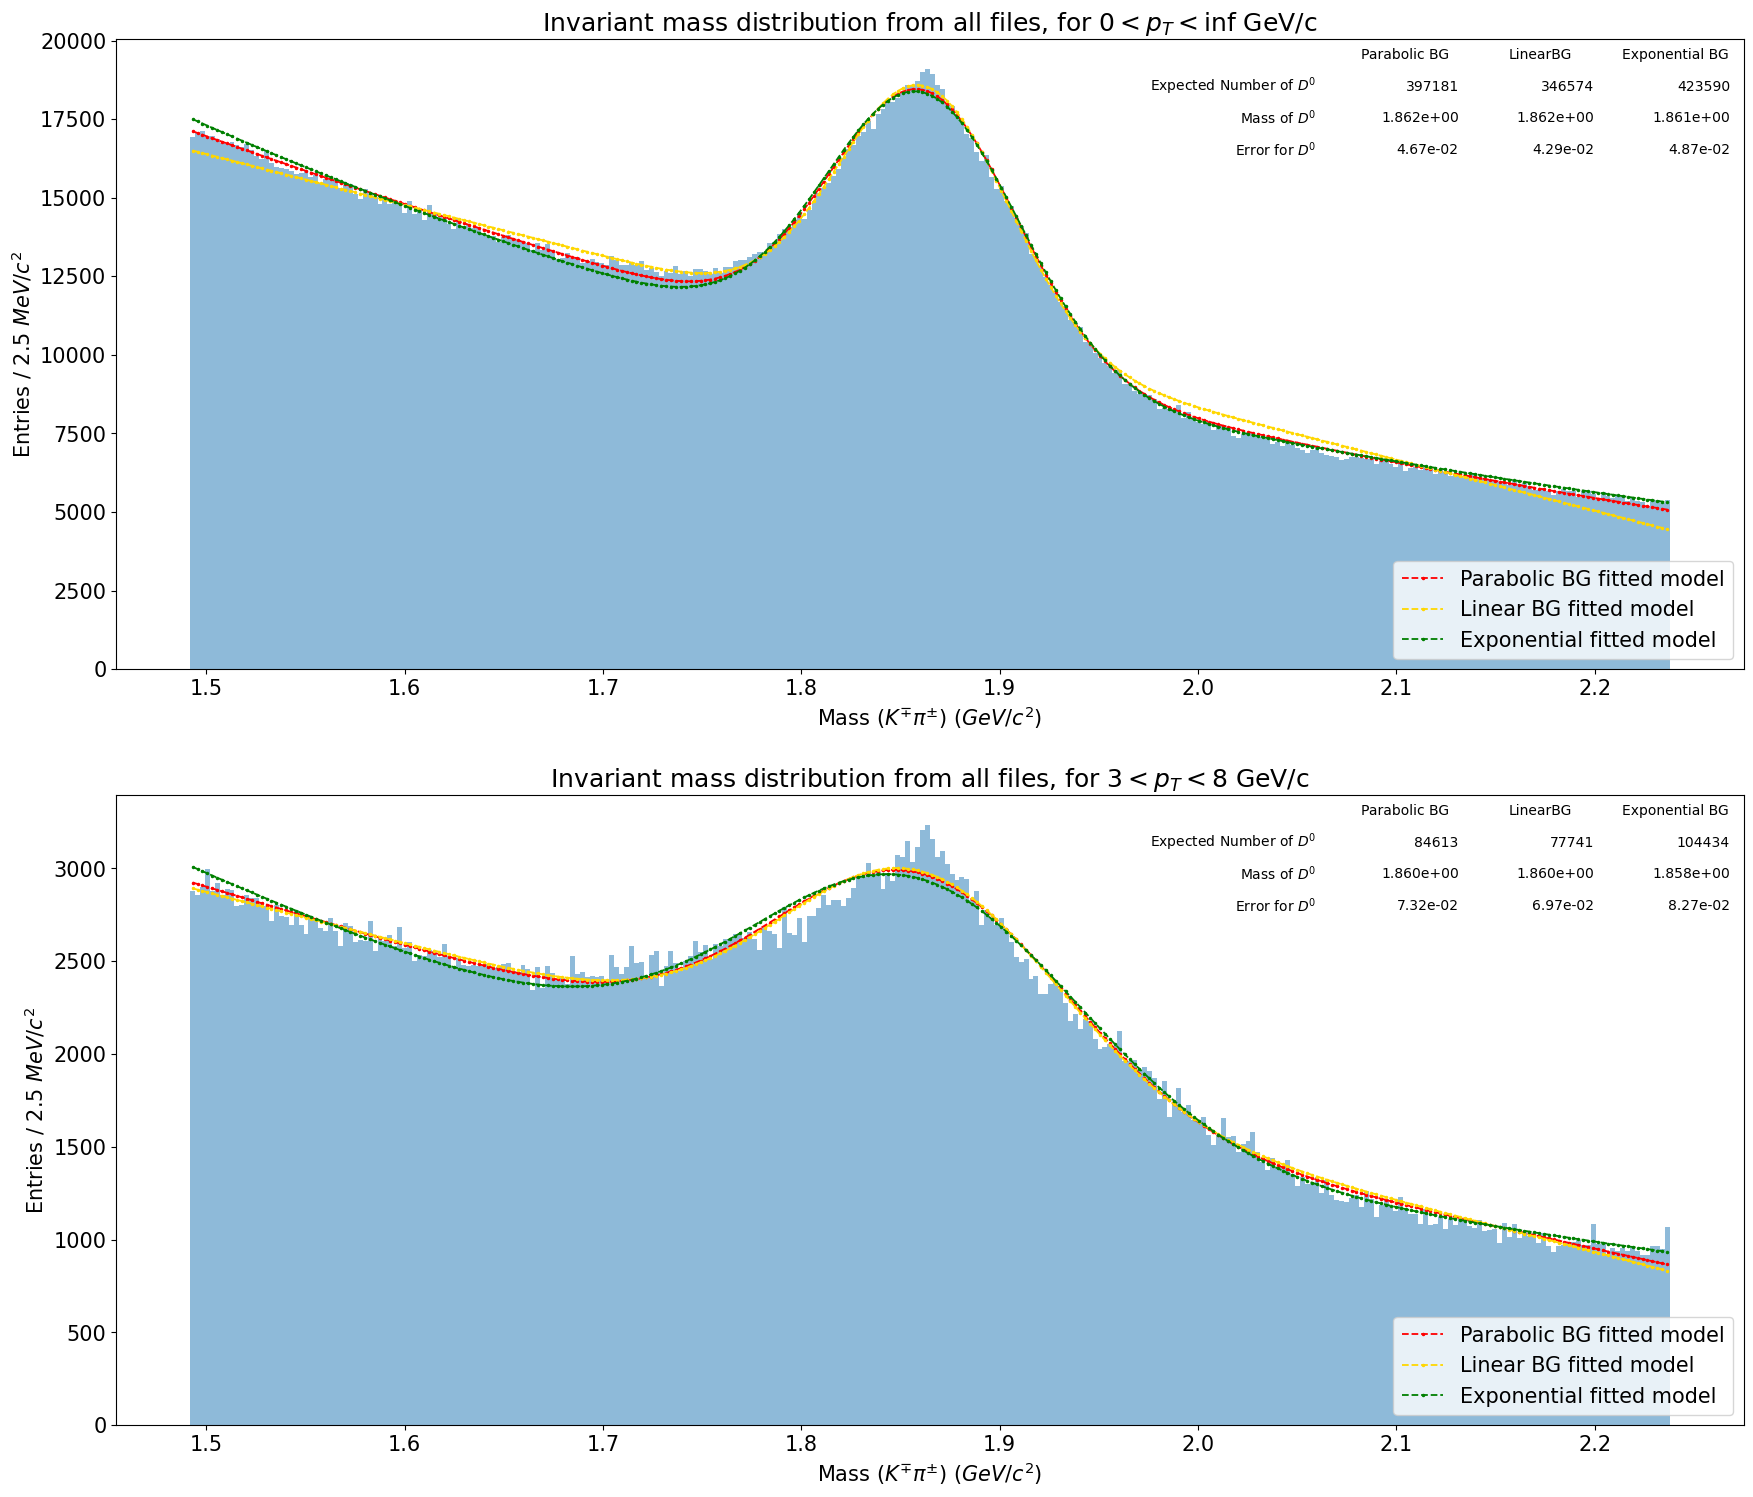

,N,pedestal,mu,sigma,pt interval
0,864.072,40700.292,1.862,0.043,"[0, inf]"
1,990.246,69969.934,1.862,0.047,"[0, inf]"
2,1056.088,30688.212,1.861,0.049,"[0, inf]"
3,193.823,7030.053,1.860,0.070,"[3, 8]"
4,210.957,9077.290,1.860,0.073,"[3, 8]"
5,260.374,5696.442,1.858,0.083,"[3, 8]"


In [16]:
def parabolic_model( x, pedestal, N, mu, sig, B, A ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + B*x + A*x**2 )
def linear_model( x, pedestal, N, mu, sig, rho ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig )  + pedestal + x * rho )
def exponential_model( x, pedestal, N, mu, sig, tau, off ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal * np.exp( ( x - off ) / tau ) )

N_BINS = 300
m_d0 = 1.86484
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
STEP = (MAX_MASS-MIN_MASS)/N_BINS

pt_extremes = [[0, np.inf], [3,8]]
times = len(pt_extremes)

N_recap = []
pedestal_recap = []
mu_recap = []
sigma_recap = []
par1_recap = []
par2_recap = []
interval_recap = []

fig, axs = plt.subplots( nrows = times, ncols = 1, figsize = ( 21, 9 * times ) )
# apporximated graph
for i in range( times ) :
    pt_lim = pt_extremes[ i ]
    ax = axs[ i ]
    mass = df[df["pt"].between(pt_lim[0], pt_lim[1])]["mass"]
    
    counts, edges, _ = ax.hist(mass, bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid", alpha=0.5)
    centers = ( edges[:-1] + edges[1:] ) / 2.
    
    # fitting the two models
    parab_fit_res = curve_fit( f = parabolic_model, xdata = centers, ydata = counts, p0 = [ 12500, 7000, m_d0, 0.1/6., -0.1, 0.01 ] )
    parab_pars = parab_fit_res[0]
    lin_fit_res = curve_fit( f = linear_model, xdata = centers, ydata = counts, p0 = [ 20000, 7000, m_d0, 0.1/6., 50000 ] )
    lin_pars = lin_fit_res[0]
    exp_fit_res = curve_fit( f = exponential_model, xdata = centers, ydata = counts, p0 = [ 20000, 7000, m_d0, 0.1/6., -0.2, m_d0 ] )
    exp_pars = exp_fit_res[0]
    # plotting the results
    ax.plot( centers, parabolic_model( centers, parab_pars[0], parab_pars[1], parab_pars[2], parab_pars[3], parab_pars[4], parab_pars[5] ),
        color='red', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Parabolic BG fitted model' )
    ax.plot( centers, linear_model( centers, lin_pars[0], lin_pars[1], lin_pars[2], lin_pars[3], lin_pars[4] ),
        color='gold', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Linear BG fitted model' )
    ax.plot( centers, exponential_model( centers, exp_pars[0], exp_pars[1], exp_pars[2], exp_pars[3], exp_pars[4], exp_pars[5] ),
        color='green', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Exponential fitted model' )

    m_parab = parab_pars[2]
    s_parab = parab_pars[3]
    K_parab = parab_pars[1]*( norm.cdf( m_parab + 3.*s_parab, loc = m_parab, scale = s_parab )
                          - norm.cdf( m_parab - 3.*s_parab, loc = m_parab, scale = s_parab ))/STEP
    m_lin = lin_pars[2]
    s_lin = lin_pars[3]
    K_lin = lin_pars[1]*( norm.cdf( m_lin + 3.*s_lin, loc = m_lin, scale = s_lin )
                          - norm.cdf( m_lin - 3.*s_lin, loc = m_lin, scale = s_lin ))/STEP
    m_exp = exp_pars[2]
    s_exp = exp_pars[3]
    K_exp = exp_pars[1]*( norm.cdf( m_exp + 3.*s_exp, loc = m_exp, scale = s_exp )
                          - norm.cdf( m_exp - 3.*s_exp, loc = m_exp, scale = s_exp ) )/STEP

    ax.table( 
        cellText = [[f"{K_parab:.0f}", f"{K_lin:.0f}", f"{K_exp:.0f}"],[ f"{m_parab:.3e}", f"{m_lin:.3e}", f"{m_exp:.3e}" ], [f"{s_parab:.2e}", f"{s_lin:.2e}", f"{s_exp:.2e}"] ],
        rowLabels = [ r'Expected Number of $D^0$', r'Mass of $D^0$', r'Error for $D^0$'],
        colLabels = [ 'Parabolic BG', 'LinearBG', 'Exponential BG' ],
        # cellColours = [ [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ] ],
        # cellColours = [ [ 'red', 'blue' ], [ 'red', 'blue' ],[ 'red', 'blue' ] ],
        bbox = [ 0.75, 0.8, 0.25, 0.2 ],
        edges = 'open',
        rowLoc = 'right',
        )
        
    # ax.text( m_parab, hist.min() + 30 , r'Expected $K_S^0$: ' + f"{K_parab:.0f}", size = 25, c= 'red', horizontalalignment='center' )
    # ax.text( m_lin, hist.min() , r'Expected $K_S^0$: ' + f"{K_lin:.0f}", size = 25, c= 'blue', horizontalalignment='center' )
    # # ax.text( m_exp, exp_pars[0], r'Expected $K_S^0$: ' + f"{K_exp:.0f}", size = 25, c= 'blue' )
    
    
    ax.set_title( r"Invariant mass distribution from all files, for " + str(pt_lim[0]) + r"$ < p_{T} <$" + str(pt_lim[1]) + r" GeV/c" )
    # to reset into linear scale, default histo for the function
    ax.set_yscale( 'linear' )
    ax.set_xlabel( r'Mass ($K^{\mp}\pi^{\pm}$) $(GeV/c^2)$')
    ax.set_ylabel( r"Entries / "+f"{STEP*1000.:.1f}"+r" $MeV/c^2$")
    ax.legend( loc = 'lower right' )

    N_recap.append(lin_pars[1]); N_recap.append(parab_pars[1]); N_recap.append(exp_pars[1]);
    pedestal_recap.append(lin_pars[0]); pedestal_recap.append(parab_pars[0]); pedestal_recap.append(exp_pars[0]);
    mu_recap.append(lin_pars[2]); mu_recap.append(parab_pars[2]); mu_recap.append(exp_pars[2]);
    sigma_recap.append(lin_pars[3]); sigma_recap.append(parab_pars[3]); sigma_recap.append(exp_pars[3]);
    #par1_recap.append()
    #par2_recap = []
    for tt in range (3):
        interval_recap.append(pt_lim)

pd.set_option("display.precision", 3)
recap = pd.DataFrame({
    "N": N_recap,
    "pedestal": pedestal_recap,
    "mu": mu_recap,
    "sigma": sigma_recap,
    "pt interval": interval_recap
})
plt.show()

recap